### Importing Libraries & Data(CSV File)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None, 'display.max_rows', None) # for displaying all columns and rows
pd.set_option('display.float_format', '{:,.2f}'.format)  # for limiting the number of decimal places
#and not showing values in scientific notation


In [3]:
cols_to_keep = [
    'SK_ID_CURR',
    'TARGET',
    # Financial
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    # Demographics
    'DAYS_BIRTH',
    'CODE_GENDER',
    'NAME_FAMILY_STATUS',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    # Employment & Education
    'NAME_EDUCATION_TYPE',
    'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE',
    'DAYS_EMPLOYED',
    # Assets
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_HOUSING_TYPE',
    # Region / Social
    'REGION_RATING_CLIENT',
    'REGION_POPULATION_RELATIVE',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    # External Scores
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    # Application Info
    'NAME_CONTRACT_TYPE',
    'WEEKDAY_APPR_PROCESS_START',
    'HOUR_APPR_PROCESS_START'
]

prev_cols = [ 'SK_ID_CURR','NAME_CONTRACT_STATUS','AMT_CREDIT','AMT_APPLICATION','AMT_ANNUITY']


In [ ]:
# Importing the high value Analysis Data from 2 files for Analysis due to system limitations

curr_data =pd.read_csv("E:\\Data\\application_data.csv",usecols=cols_to_keep,low_memory=False)
prev_data = pd.read_csv("E:\\Data\\previous_application.csv",usecols=prev_cols,low_memory=False)

### User-Defined Functions Used in The File/EDA

In [5]:
def employed_Years_group(years):
    if pd.isna(years) or years == 0:
        return "No Employment Info"
    elif years < 3:
        return "0-3 years"
    elif years < 6:
        return "3-6 years"
    elif years < 10:
        return "6-10 years"
    else:
        return "10+ years"



In [6]:
def Age_group(age):
    if pd.isna(age) or age < 18 :
        return "No Age Info or UnderAge"
    elif age < 25:
        return "18-25"
    elif age < 40:
        return "25-40"
    elif age < 60:
        return "40-60"
    else:
        return "60+"

In [7]:
def loan_group(credit):
    if credit < 300000:
        return "Small Loan"
    elif credit < 800000:
        return "Medium Loan"
    elif credit < 1500000:
        return "Large Loan"
    else:
        return "Very Large Loan"

In [8]:
def income_group(income):
    if income < 75000:
        return "Low Income"
    elif income < 150000:
        return "Lower Middle Income"
    elif income < 300000:
        return "Upper Middle Income"
    else:
        return "High Income"

# 1.Data Understanding and Data Cleaning

In [9]:
curr_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,Laborers,1.00,2,WEDNESDAY,10,0.08,0.26,0.14,2.00,2.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,Core staff,2.00,1,MONDAY,11,0.31,0.62,NaN,1.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,Laborers,1.00,2,MONDAY,9,NaN,0.56,0.73,0.00,0.00
3,100006,0,Cash loans,F,N,Y,0,"135,000.00","312,682.50","29,686.50","297,000.00",Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,-19005,-3039,Laborers,2.00,2,WEDNESDAY,17,NaN,0.65,NaN,2.00,0.00
4,100007,0,Cash loans,M,N,Y,0,"121,500.00","513,000.00","21,865.50","513,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.03,-19932,-3038,Core staff,1.00,2,THURSDAY,11,NaN,0.32,NaN,0.00,0.00


In [10]:
curr_data.info() # Getting the data type of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   SK_ID_CURR                  307511 non-null  int64  
 1   TARGET                      307511 non-null  int64  
 2   NAME_CONTRACT_TYPE          307511 non-null  object 
 3   CODE_GENDER                 307511 non-null  object 
 4   FLAG_OWN_CAR                307511 non-null  object 
 5   FLAG_OWN_REALTY             307511 non-null  object 
 6   CNT_CHILDREN                307511 non-null  int64  
 7   AMT_INCOME_TOTAL            307511 non-null  float64
 8   AMT_CREDIT                  307511 non-null  float64
 9   AMT_ANNUITY                 307499 non-null  float64
 10  AMT_GOODS_PRICE             307233 non-null  float64
 11  NAME_INCOME_TYPE            307511 non-null  object 
 12  NAME_EDUCATION_TYPE         307511 non-null  object 
 13  NAME_FAMILY_ST

In [11]:
# Null/Missing Value Percentage in Each Coloumn
((curr_data.isna().sum()/307511)*100).sort_values(ascending=False) # Getting the null values in each column

EXT_SOURCE_1                 56.38
OCCUPATION_TYPE              31.35
EXT_SOURCE_3                 19.83
OBS_30_CNT_SOCIAL_CIRCLE      0.33
DEF_30_CNT_SOCIAL_CIRCLE      0.33
EXT_SOURCE_2                  0.21
AMT_GOODS_PRICE               0.09
AMT_ANNUITY                   0.00
CNT_FAM_MEMBERS               0.00
CODE_GENDER                   0.00
SK_ID_CURR                    0.00
TARGET                        0.00
NAME_INCOME_TYPE              0.00
AMT_CREDIT                    0.00
CNT_CHILDREN                  0.00
AMT_INCOME_TOTAL              0.00
FLAG_OWN_REALTY               0.00
FLAG_OWN_CAR                  0.00
NAME_CONTRACT_TYPE            0.00
NAME_EDUCATION_TYPE           0.00
DAYS_BIRTH                    0.00
DAYS_EMPLOYED                 0.00
NAME_HOUSING_TYPE             0.00
REGION_POPULATION_RELATIVE    0.00
NAME_FAMILY_STATUS            0.00
HOUR_APPR_PROCESS_START       0.00
REGION_RATING_CLIENT          0.00
WEEKDAY_APPR_PROCESS_START    0.00
dtype: float64

In [12]:
prev_data.head()

,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,NAME_CONTRACT_STATUS
0,271877,"1,730.43","17,145.00","17,145.00",Approved
1,108129,"25,188.62","607,500.00","679,671.00",Approved
2,122040,"15,060.74","112,500.00","136,444.50",Approved
3,176158,"47,041.33","450,000.00","470,790.00",Approved
4,202054,"31,924.40","337,500.00","404,055.00",Refused


In [13]:
prev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 5 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   SK_ID_CURR            1670214 non-null  int64  
 1   AMT_ANNUITY           1297979 non-null  float64
 2   AMT_APPLICATION       1670214 non-null  float64
 3   AMT_CREDIT            1670213 non-null  float64
 4   NAME_CONTRACT_STATUS  1670214 non-null  object 
dtypes: float64(3), int64(1), object(1)
memory usage: 63.7+ MB


In [14]:
# Null/Missing Value Percentage in Each Column of Prev_Data
((prev_data.isna().sum()/1670214)*100).sort_values(ascending=False)

AMT_ANNUITY            22.29
AMT_CREDIT              0.00
SK_ID_CURR              0.00
AMT_APPLICATION         0.00
NAME_CONTRACT_STATUS    0.00
dtype: float64

In [15]:
curr_data['DAYS_BIRTH']= curr_data['DAYS_BIRTH'].abs().round(0).astype(int)
curr_data['AGE'] = curr_data['DAYS_BIRTH']/365
curr_data['YEARS_EMPLOYED'] = (curr_data['DAYS_EMPLOYED'].abs()/365).round(2)
curr_data.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,AGE,YEARS_EMPLOYED
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.02,9461,-637,Laborers,1.00,2,WEDNESDAY,10,0.08,0.26,0.14,2.00,2.00,25.92,1.75
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",State servant,Higher education,Married,House / apartment,0.00,16765,-1188,Core staff,2.00,1,MONDAY,11,0.31,0.62,NaN,1.00,0.00,45.93,3.25
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.01,19046,-225,Laborers,1.00,2,MONDAY,9,NaN,0.56,0.73,0.00,0.00,52.18,0.62
3,100006,0,Cash loans,F,N,Y,0,"135,000.00","312,682.50","29,686.50","297,000.00",Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,19005,-3039,Laborers,2.00,2,WEDNESDAY,17,NaN,0.65,NaN,2.00,0.00,52.07,8.33
4,100007,0,Cash loans,M,N,Y,0,"121,500.00","513,000.00","21,865.50","513,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.03,19932,-3038,Core staff,1.00,2,THURSDAY,11,NaN,0.32,NaN,0.00,0.00,54.61,8.32


In [16]:
curr_data[['AGE','YEARS_EMPLOYED']].describe()

,AGE,YEARS_EMPLOYED
count,"307,511.00","307,511.00"
mean,43.94,185.55
std,11.96,382.04
min,20.52,0.00
25%,34.01,2.56
50%,43.15,6.08
75%,53.92,15.64
max,69.12,"1,000.67"


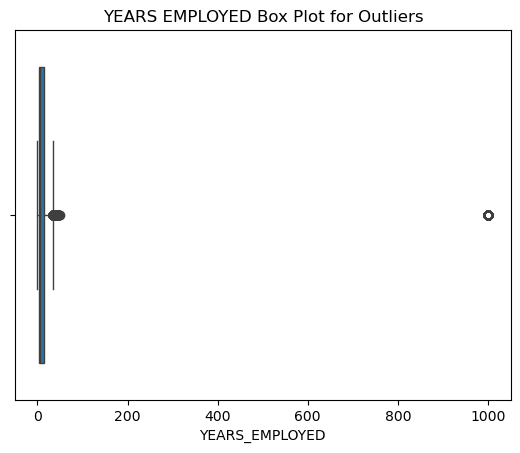

In [17]:
sns.boxplot(x= curr_data['YEARS_EMPLOYED'])
plt.title('YEARS EMPLOYED Box Plot for Outliers')
plt.show()

In [18]:
curr_data.loc[curr_data['YEARS_EMPLOYED']>50,'YEARS_EMPLOYED'] = np.nan # Fixing the outlier in YEARS_EMPLOYED column changing it to NaN

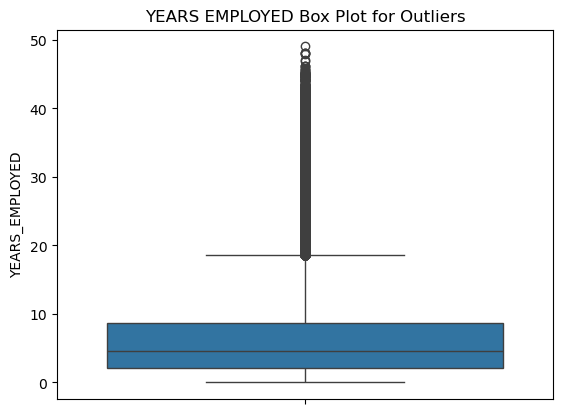

In [19]:
# Rechecking the distribution of YEARS_EMPLOYED column
sns.boxplot(curr_data['YEARS_EMPLOYED'])
plt.title('YEARS EMPLOYED Box Plot for Outliers')
plt.show()

# Observation: The Outliers have been fixed in YEARS_EMPLOYED
# the observations seemingly outlier in chart are valid values and does not need to be fixed
# instead later grouping them will be better for analysis

In [20]:
# Grouping YEARS_EMPLOYED into Groups 

curr_data['EMPLOYMENT_DURATION_GROUP'] = curr_data['YEARS_EMPLOYED'].apply(employed_Years_group)

In [21]:
# Removing YEARS_EMPLOYED, DAYS_BIRTH and DAYS_EMPLOYED columns ass we have age and employment_duration_group columns
curr_data = curr_data.drop(['DAYS_BIRTH','DAYS_EMPLOYED'],axis=1)
curr_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,AGE,YEARS_EMPLOYED,EMPLOYMENT_DURATION_GROUP
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.02,Laborers,1.00,2,WEDNESDAY,10,0.08,0.26,0.14,2.00,2.00,25.92,1.75,0-3 years
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",State servant,Higher education,Married,House / apartment,0.00,Core staff,2.00,1,MONDAY,11,0.31,0.62,NaN,1.00,0.00,45.93,3.25,3-6 years
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.01,Laborers,1.00,2,MONDAY,9,NaN,0.56,0.73,0.00,0.00,52.18,0.62,0-3 years
3,100006,0,Cash loans,F,N,Y,0,"135,000.00","312,682.50","29,686.50","297,000.00",Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,Laborers,2.00,2,WEDNESDAY,17,NaN,0.65,NaN,2.00,0.00,52.07,8.33,6-10 years
4,100007,0,Cash loans,M,N,Y,0,"121,500.00","513,000.00","21,865.50","513,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.03,Core staff,1.00,2,THURSDAY,11,NaN,0.32,NaN,0.00,0.00,54.61,8.32,6-10 years


In [22]:
# Grouping Age and then drop the age column
curr_data['AGE_GROUP'] = curr_data['AGE'].apply(Age_group) # applying the function to create a new column (age_group)

curr_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,AGE,YEARS_EMPLOYED,EMPLOYMENT_DURATION_GROUP,AGE_GROUP
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.02,Laborers,1.00,2,WEDNESDAY,10,0.08,0.26,0.14,2.00,2.00,25.92,1.75,0-3 years,25-40
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",State servant,Higher education,Married,House / apartment,0.00,Core staff,2.00,1,MONDAY,11,0.31,0.62,NaN,1.00,0.00,45.93,3.25,3-6 years,40-60
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.01,Laborers,1.00,2,MONDAY,9,NaN,0.56,0.73,0.00,0.00,52.18,0.62,0-3 years,40-60
3,100006,0,Cash loans,F,N,Y,0,"135,000.00","312,682.50","29,686.50","297,000.00",Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,Laborers,2.00,2,WEDNESDAY,17,NaN,0.65,NaN,2.00,0.00,52.07,8.33,6-10 years,40-60
4,100007,0,Cash loans,M,N,Y,0,"121,500.00","513,000.00","21,865.50","513,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.03,Core staff,1.00,2,THURSDAY,11,NaN,0.32,NaN,0.00,0.00,54.61,8.32,6-10 years,40-60


In [23]:
# Capping the data for AMT_INCOME_TOTAL
income_cap = curr_data['AMT_INCOME_TOTAL'].quantile(0.99)
curr_data['Capped_AMT_INCOME_TOTAL'] = curr_data['AMT_INCOME_TOTAL'].apply(lambda x: income_cap if x>income_cap else x)

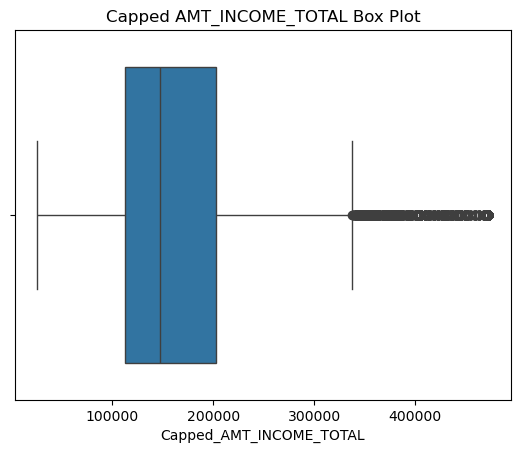

In [24]:
sns.boxplot(x = curr_data['Capped_AMT_INCOME_TOTAL'])
plt.title('Capped AMT_INCOME_TOTAL Box Plot')
plt.show()

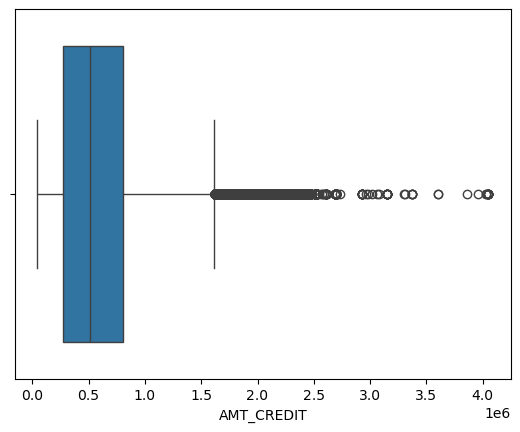

In [25]:
sns.boxplot(x=curr_data['AMT_CREDIT'])
plt.show()



In [26]:
# Feature Engineering for CREDIT_INCOME_RATIO and ANNUITY_INCOME_RATIO
curr_data['CREDIT_INCOME_RATIO'] = curr_data['AMT_CREDIT'] / curr_data['AMT_INCOME_TOTAL']
curr_data['ANNUITY_INCOME_RATIO'] = curr_data['AMT_ANNUITY'] / curr_data['AMT_INCOME_TOTAL']
curr_data.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,AGE,YEARS_EMPLOYED,EMPLOYMENT_DURATION_GROUP,AGE_GROUP,Capped_AMT_INCOME_TOTAL,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.02,Laborers,1.00,2,WEDNESDAY,10,0.08,0.26,0.14,2.00,2.00,25.92,1.75,0-3 years,25-40,"202,500.00",2.01,0.12
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",State servant,Higher education,Married,House / apartment,0.00,Core staff,2.00,1,MONDAY,11,0.31,0.62,NaN,1.00,0.00,45.93,3.25,3-6 years,40-60,"270,000.00",4.79,0.13
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.01,Laborers,1.00,2,MONDAY,9,NaN,0.56,0.73,0.00,0.00,52.18,0.62,0-3 years,40-60,"67,500.00",2.00,0.10
3,100006,0,Cash loans,F,N,Y,0,"135,000.00","312,682.50","29,686.50","297,000.00",Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,Laborers,2.00,2,WEDNESDAY,17,NaN,0.65,NaN,2.00,0.00,52.07,8.33,6-10 years,40-60,"135,000.00",2.32,0.22
4,100007,0,Cash loans,M,N,Y,0,"121,500.00","513,000.00","21,865.50","513,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.03,Core staff,1.00,2,THURSDAY,11,NaN,0.32,NaN,0.00,0.00,54.61,8.32,6-10 years,40-60,"121,500.00",4.22,0.18


In [27]:
# Family Size Data consistency
(curr_data['CNT_FAM_MEMBERS']< curr_data['CNT_CHILDREN']).sum()

np.int64(0)

In [28]:
(curr_data['AMT_CREDIT'] < curr_data['AMT_GOODS_PRICE']).sum()


np.int64(260)

In [29]:
curr_data['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [30]:
curr_data['NAME_HOUSING_TYPE'].value_counts()

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

In [31]:
curr_data['NAME_FAMILY_STATUS'].value_counts()

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

In [32]:
curr_data['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [33]:
curr_data['INCOME_GROUP'] = curr_data['AMT_INCOME_TOTAL'].apply(income_group)
curr_data['LOAN_SIZE_GROUP'] = curr_data['AMT_CREDIT'].apply(loan_group)

In [34]:
# identifying Nan and Treating it
(curr_data.isna().sum()/len(curr_data)*100).sort_values(ascending=False)

EXT_SOURCE_1                 56.38
OCCUPATION_TYPE              31.35
EXT_SOURCE_3                 19.83
YEARS_EMPLOYED               18.01
OBS_30_CNT_SOCIAL_CIRCLE      0.33
DEF_30_CNT_SOCIAL_CIRCLE      0.33
EXT_SOURCE_2                  0.21
AMT_GOODS_PRICE               0.09
AMT_ANNUITY                   0.00
ANNUITY_INCOME_RATIO          0.00
CNT_FAM_MEMBERS               0.00
NAME_CONTRACT_TYPE            0.00
TARGET                        0.00
SK_ID_CURR                    0.00
AMT_INCOME_TOTAL              0.00
CNT_CHILDREN                  0.00
FLAG_OWN_REALTY               0.00
CODE_GENDER                   0.00
FLAG_OWN_CAR                  0.00
REGION_RATING_CLIENT          0.00
REGION_POPULATION_RELATIVE    0.00
NAME_FAMILY_STATUS            0.00
NAME_HOUSING_TYPE             0.00
NAME_EDUCATION_TYPE           0.00
NAME_INCOME_TYPE              0.00
AMT_CREDIT                    0.00
HOUR_APPR_PROCESS_START       0.00
AGE                           0.00
WEEKDAY_APPR_PROCESS

In [35]:
curr_data = curr_data.drop(['EXT_SOURCE_1'],axis=1) # Dropping it Since more than 50% of data is missing or not available
curr_data['OCCUPATION_TYPE'].fillna('Unknown',inplace=True) # Filling with Unknown since more than 30% of data is missing or not available
curr_data['EXT_SOURCE_3'].fillna(curr_data['EXT_SOURCE_3'].median(),inplace=True) # Filling with median since more than 20% of data is missing or not available
small_missing = [
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'EXT_SOURCE_2',
    'AMT_GOODS_PRICE'
] # List of columns with less than 1% missing

for col in small_missing:
    curr_data[col] = curr_data[col].fillna(curr_data[col].median()) # Filling with median since less than 1% of data is missing or not available


In [ ]:

curr_data['AMT_ANNUITY'].fillna(curr_data['AMT_ANNUITY'].median(),inplace=True)
curr_data['ANNUITY_INCOME_RATIO'] = curr_data['AMT_ANNUITY'] / curr_data['AMT_INCOME_TOTAL']
curr_data['CNT_FAM_MEMBERS'].fillna(curr_data['CNT_FAM_MEMBERS'].median(),inplace=True)
curr_data.isna().sum().sort_values(ascending=False)

# Note:- No more missing values left unintentionally in curr_data data set

### Note:
 All missing values in the current application dataset have been treated using appropriate methods.
 Numerical columns with very small missing percentages were imputed using median values.
 Categorical columns with moderate missing values were filled with 'Unknown'.
 The only column intentionally left with missing values is YEARS_EMPLOYED, as missing employment duration
 carries meaningful information (e.g., unemployed, retired, or unknown employment status) and is handled
 through the derived EMPLOYMENT_STABILITY feature.


### Prev_data dataset Cleaning and Understanding


In [ ]:
prev_data.head()

,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,NAME_CONTRACT_STATUS
0,271877,"1,730.43","17,145.00","17,145.00",Approved
1,108129,"25,188.62","607,500.00","679,671.00",Approved
2,122040,"15,060.74","112,500.00","136,444.50",Approved
3,176158,"47,041.33","450,000.00","470,790.00",Approved
4,202054,"31,924.40","337,500.00","404,055.00",Refused


In [ ]:
prev_data['NAME_CONTRACT_STATUS'].value_counts()

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

In [ ]:
prev_summary = prev_data.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT': ['count', 'mean', 'sum'],
    'AMT_ANNUITY': 'mean',
    'NAME_CONTRACT_STATUS': lambda x: (x == 'Refused').sum()
})


In [ ]:
prev_summary.columns = [
    'PREV_LOAN_COUNT',
    'PREV_CREDIT_MEAN',
    'PREV_CREDIT_SUM',
    'PREV_ANNUITY_MEAN',
    'PREV_REFUSED_COUNT'
]

prev_summary.reset_index(inplace=True)


In [ ]:
prev_summary.head()

,SK_ID_CURR,PREV_LOAN_COUNT,PREV_CREDIT_MEAN,PREV_CREDIT_SUM,PREV_ANNUITY_MEAN,PREV_REFUSED_COUNT
0,100001,1,"23,787.00","23,787.00","3,951.00",0
1,100002,1,"179,055.00","179,055.00","9,251.77",0
2,100003,3,"484,191.00","1,452,573.00","56,553.99",0
3,100004,1,"20,106.00","20,106.00","5,357.25",0
4,100005,2,"20,076.75","40,153.50","4,813.20",0


In [ ]:
curr_data = curr_data.merge(prev_summary, how='left', on='SK_ID_CURR')

In [ ]:
prev_cols = [
    'PREV_LOAN_COUNT',
    'PREV_CREDIT_MEAN',
    'PREV_CREDIT_SUM',
    'PREV_ANNUITY_MEAN',
    'PREV_REFUSED_COUNT'
]

curr_data[prev_cols] = curr_data[prev_cols].fillna(0)


In [ ]:
curr_data.shape # To check if aggregated data was successfully  and data was merged correctly


(307511, 39)

In [ ]:
curr_data.to_csv('Cleaned_Credit_Data.csv',index=False) # Saving Cleaned Data in a new File for ease of access to cleaned-data in future analysis

In [ ]:
curr_data[['PREV_LOAN_COUNT','PREV_REFUSED_COUNT']].describe()


,PREV_LOAN_COUNT,PREV_REFUSED_COUNT
count,"307,511.00","307,511.00"
mean,4.60,0.80
std,4.18,1.77
min,0.00,0.00
25%,2.00,0.00
50%,3.00,0.00
75%,6.00,1.00
max,73.00,68.00


In [ ]:
curr_data[['PREV_LOAN_COUNT','PREV_REFUSED_COUNT']].isna().sum()


PREV_LOAN_COUNT       0
PREV_REFUSED_COUNT    0
dtype: int64

In [ ]:
curr_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,AGE,YEARS_EMPLOYED,EMPLOYMENT_DURATION_GROUP,AGE_GROUP,Capped_AMT_INCOME_TOTAL,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,INCOME_GROUP,LOAN_SIZE_GROUP,PREV_LOAN_COUNT,PREV_CREDIT_MEAN,PREV_CREDIT_SUM,PREV_ANNUITY_MEAN,PREV_REFUSED_COUNT
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.02,Laborers,1.00,2,WEDNESDAY,10,0.26,0.14,2.00,2.00,25.92,1.75,0-3 years,25-40,"202,500.00",2.01,0.12,Upper Middle Income,Medium Loan,1.00,"179,055.00","179,055.00","9,251.77",0.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",State servant,Higher education,Married,House / apartment,0.00,Core staff,2.00,1,MONDAY,11,0.62,0.54,1.00,0.00,45.93,3.25,3-6 years,40-60,"270,000.00",4.79,0.13,Upper Middle Income,Large Loan,3.00,"484,191.00","1,452,573.00","56,553.99",0.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.01,Laborers,1.00,2,MONDAY,9,0.56,0.73,0.00,0.00,52.18,0.62,0-3 years,40-60,"67,500.00",2.00,0.10,Low Income,Small Loan,1.00,"20,106.00","20,106.00","5,357.25",0.00
3,100006,0,Cash loans,F,N,Y,0,"135,000.00","312,682.50","29,686.50","297,000.00",Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,Laborers,2.00,2,WEDNESDAY,17,0.65,0.54,2.00,0.00,52.07,8.33,6-10 years,40-60,"135,000.00",2.32,0.22,Lower Middle Income,Medium Loan,9.00,"291,695.50","2,625,259.50","23,651.17",1.00
4,100007,0,Cash loans,M,N,Y,0,"121,500.00","513,000.00","21,865.50","513,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.03,Core staff,1.00,2,THURSDAY,11,0.32,0.54,0.00,0.00,54.61,8.32,6-10 years,40-60,"121,500.00",4.22,0.18,Lower Middle Income,Medium Loan,6.00,"166,638.75","999,832.50","12,278.81",0.00


# What we infered from Data Till Now
## 📌 Data Preparation Summary (Before EDA)

### 🔹 Objective  
The objective of this project is to analyze customer and loan-related attributes to identify patterns associated with difficulty in repaying loans. Before performing exploratory data analysis (EDA), the dataset was cleaned, validated, and transformed to ensure accuracy and interpretability.

---

### 🔹 Data Understanding  
The dataset consists of two main components:
- **Current application data** containing demographic, financial, and loan details of customers at the time of application.
- **Previous application data** containing historical loan application records of customers.

Both datasets were reviewed to understand data types, missing values, and potential inconsistencies.

---

### 🔹 Missing Value Treatment  
Missing values were handled according to their nature and proportion:

- Columns with **very high missing values** were removed due to insufficient data coverage.
- **Categorical variables** with moderate missing values were filled with `"Unknown"` to preserve meaningful patterns.
- **Numerical variables** with small percentages of missing values were imputed using the **median** to avoid distortion from extreme values.
- Missing employment duration was retained intentionally because it carries meaningful information (e.g., unemployed, retired, or unknown employment status) and was handled through grouped employment features.

---

### 🔹 Data Cleaning and Feature Engineering  

Several raw variables were transformed into business-friendly and interpretable features:

| Original Variable | Transformation | New Feature |
|------------------|----------------|-------------|
| DAYS_BIRTH | Converted from days to years | AGE |
| Age | Grouped into life-stage categories | AGE_GROUP |
| DAYS_EMPLOYED | Cleaned anomalies and converted | YEARS_EMPLOYED |
| Employment duration | Grouped into stability levels | EMPLOYMENT_DURATION_GROUP |
| Income | Grouped into financial tiers | INCOME_GROUP |
| Loan amount | Grouped into size tiers | LOAN_SIZE_GROUP |

These transformations improve interpretability and help analyze customer stability.

---

### 🔹 Outlier Analysis  
Income and loan amount distributions were found to be highly right-skewed, with a small number of very high values. These values were retained as they represent genuine high-income or high-loan applicants. For better visualization, capped versions of variables were used where necessary.

---

### 🔹 Financial Risk Indicators Created  
To capture repayment burden, the following derived metrics were created:

- **Credit-to-Income Ratio** = Loan amount / Income  
- **Annuity-to-Income Ratio** = Installment amount / Income  

These ratios represent financial stress and are expected to be strong indicators of default risk.

---

### 🔹 Historical Loan Behavior Features  
Previous application data was aggregated at the customer level to generate behavioral indicators:

| Feature | Meaning |
|---------|---------|
| PREV_LOAN_COUNT | Number of previous loan applications |
| PREV_REFUSED_COUNT | Number of past loan refusals |
| PREV_CREDIT_MEAN | Average past loan amount |
| PREV_CREDIT_SUM | Total past borrowing |
| PREV_ANNUITY_MEAN | Average past installment burden |

These features provide insight into a customer’s past credit behavior.

---

### 🔹 Final Dataset Status  
At the end of the data preparation phase:

- All unintentional missing values were treated  
- No inconsistent or impossible values remain  
- Business-friendly grouped variables were created  
- Historical loan behavior was incorporated  

The dataset is now fully prepared for **Exploratory Data Analysis (EDA)** to identify patterns associated with loan repayment difficulty.


# Data Understanding and Cleaning Done Till Here. from now EDA and Visualiztion will take place

In [4]:
curr_data = pd.read_csv('Cleaned_Credit_Data.csv') 
curr_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,AGE,YEARS_EMPLOYED,EMPLOYMENT_DURATION_GROUP,AGE_GROUP,Capped_AMT_INCOME_TOTAL,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,INCOME_GROUP,LOAN_SIZE_GROUP,PREV_LOAN_COUNT,PREV_CREDIT_MEAN,PREV_CREDIT_SUM,PREV_ANNUITY_MEAN,PREV_REFUSED_COUNT
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.02,Laborers,1.00,2,WEDNESDAY,10,0.26,0.14,2.00,2.00,25.92,1.75,0-3 years,25-40,"202,500.00",2.01,0.12,Upper Middle Income,Medium Loan,1.00,"179,055.00","179,055.00","9,251.77",0.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",State servant,Higher education,Married,House / apartment,0.00,Core staff,2.00,1,MONDAY,11,0.62,0.54,1.00,0.00,45.93,3.25,3-6 years,40-60,"270,000.00",4.79,0.13,Upper Middle Income,Large Loan,3.00,"484,191.00","1,452,573.00","56,553.99",0.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.01,Laborers,1.00,2,MONDAY,9,0.56,0.73,0.00,0.00,52.18,0.62,0-3 years,40-60,"67,500.00",2.00,0.10,Low Income,Small Loan,1.00,"20,106.00","20,106.00","5,357.25",0.00
3,100006,0,Cash loans,F,N,Y,0,"135,000.00","312,682.50","29,686.50","297,000.00",Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,Laborers,2.00,2,WEDNESDAY,17,0.65,0.54,2.00,0.00,52.07,8.33,6-10 years,40-60,"135,000.00",2.32,0.22,Lower Middle Income,Medium Loan,9.00,"291,695.50","2,625,259.50","23,651.17",1.00
4,100007,0,Cash loans,M,N,Y,0,"121,500.00","513,000.00","21,865.50","513,000.00",Working,Secondary / secondary special,Single / not married,House / apartment,0.03,Core staff,1.00,2,THURSDAY,11,0.32,0.54,0.00,0.00,54.61,8.32,6-10 years,40-60,"121,500.00",4.22,0.18,Lower Middle Income,Medium Loan,6.00,"166,638.75","999,832.50","12,278.81",0.00


In [5]:
target_counts = curr_data['TARGET'].value_counts()
target_percentage = curr_data['TARGET'].value_counts(normalize= True) * 100
print(target_counts)
print(target_percentage)

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0   91.93
1    8.07
Name: proportion, dtype: float64


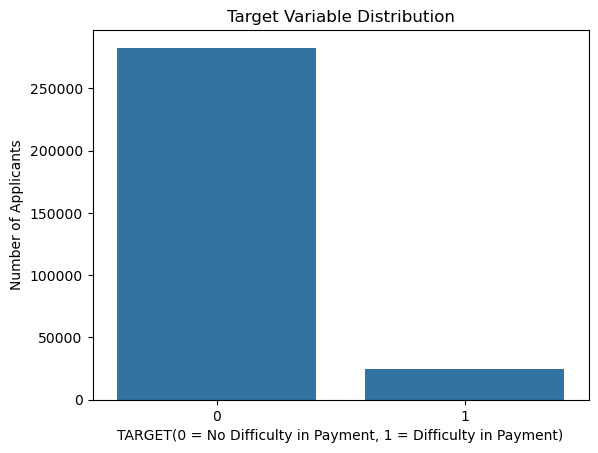

In [6]:
sns.countplot(x='TARGET',data = curr_data)
plt.title('Target Variable Distribution')
plt.xlabel('TARGET(0 = No Difficulty in Payment, 1 = Difficulty in Payment)')
plt.ylabel('Number of Applicants')
plt.show()

# Observation: The distribution of TARGET variable is imbalanced and there are more customers with No difficulty in payment
# ( 91.93% have no difficulty in payment)
# (and 8.07% have difficulty in payment)

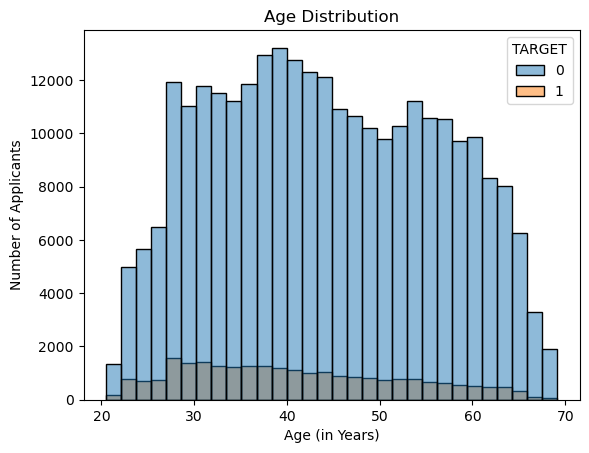

In [7]:
sns.histplot(x= curr_data['AGE'],bins = 30, hue= curr_data['TARGET'])
plt.title('Age Distribution')
plt.xlabel('Age (in Years)')
plt.ylabel('Number of Applicants')
plt.show()

# Observation 1 : Most of Applicant are between 30 to 50 and the number of applicant is very less before age of 25 and after age of 65
# Observstion 2: Payment Difficulty is more in Younger Age Group and reduces as Age Increases   

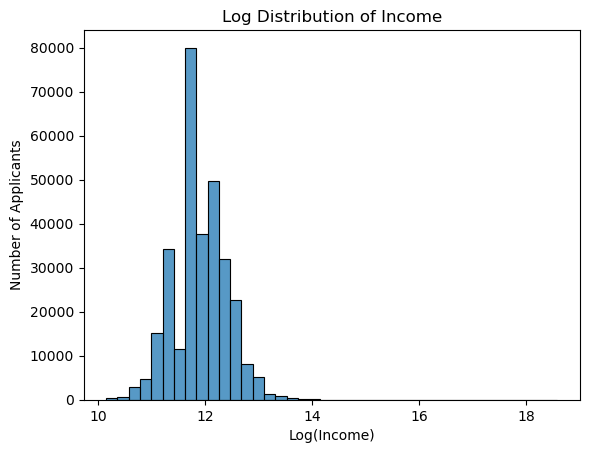

In [8]:
sns.histplot(np.log1p(curr_data['AMT_INCOME_TOTAL']), bins=40)
plt.title('Log Distribution of Income')
plt.xlabel('Log(Income)')
plt.ylabel('Number of Applicants')
plt.show()

# Observstion 1: The distribution is Right Skewed
# Observstion 2: The most applicants are in middle income bracket and very few in Lower and Upper side 


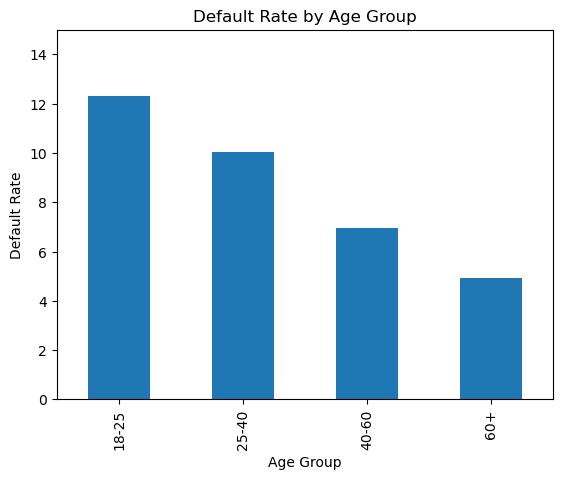

In [9]:
age_default_rate = (curr_data.groupby('AGE_GROUP')['TARGET'].mean()*100).sort_values(ascending=False)
age_default_rate.plot(kind='bar' )
plt.title('Default Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Default Rate')
plt.ylim(0,15)
plt.show()

# Observation: Age group between 18 to 25 has highest default rate and reducing as age increases soldifying earilier analysis on Age 

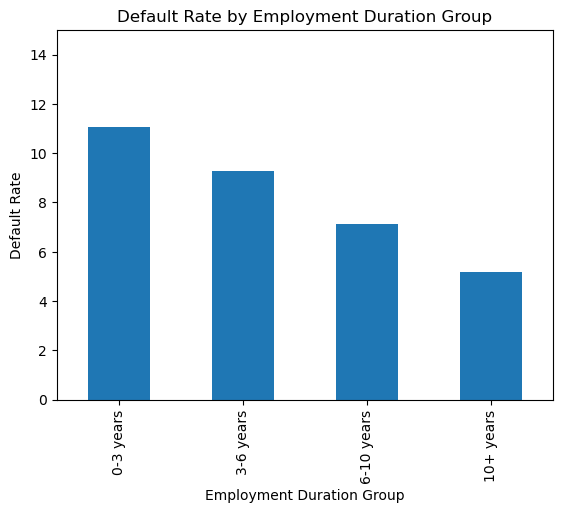

In [10]:
employment_stability = (curr_data.groupby('EMPLOYMENT_DURATION_GROUP')['TARGET'].mean()*100).sort_values(ascending=False)
employment_stability = employment_stability.drop(['No Employment Info'])
employment_stability.plot(kind = 'bar')
plt.title('Default Rate by Employment Duration Group')
plt.xlabel('Employment Duration Group')
plt.ylabel('Default Rate')
plt.ylim(0,15)
plt.show()

# Observstion : Employment Duration Group between 0-3 has highest default rate and reduces as Employment Duration Increases

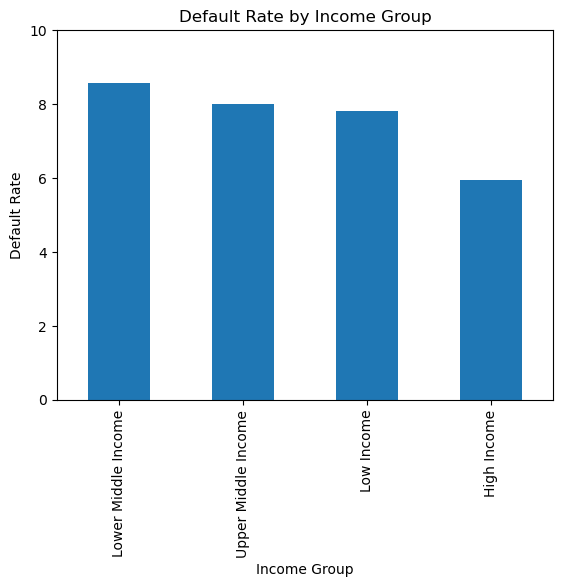

In [11]:
income_default = (curr_data.groupby('INCOME_GROUP')['TARGET'].mean()*100).sort_values(ascending=False)
income_default.plot(kind = 'bar')
plt.title('Default Rate by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Default Rate')
plt.ylim(0,10)
plt.show()
# Observstion : Default Rate is genrally equal in Low, Lower-Middle, Upper-Middle Income Groups with higest in Lower-Middle Income Group
# but High Income Group has lower compared to other groups

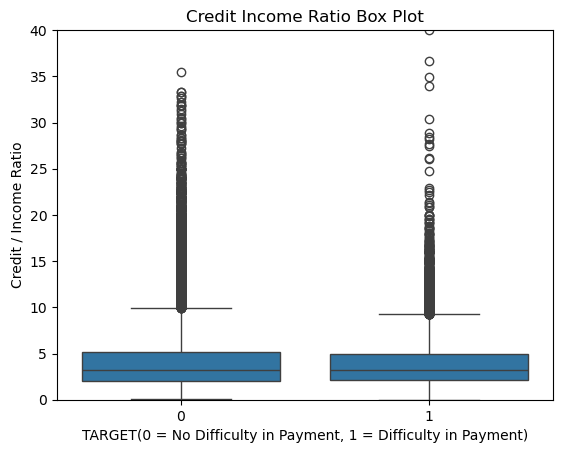

In [12]:
sns.boxplot(x= 'TARGET', y= 'CREDIT_INCOME_RATIO', data = curr_data)
plt.title('Credit Income Ratio Box Plot')
plt.xlabel('TARGET(0 = No Difficulty in Payment, 1 = Difficulty in Payment)')
plt.ylabel('Credit / Income Ratio')
plt.ylim(0,40) # Cap to remove Extreme Visual Distortion
plt.show()
# Observations: Customers who take loans that are large relative to their income are more likely to face repayment difficulties. 
# A higher credit-to-income ratio indicates greater financial burden and reduced repayment capacity.


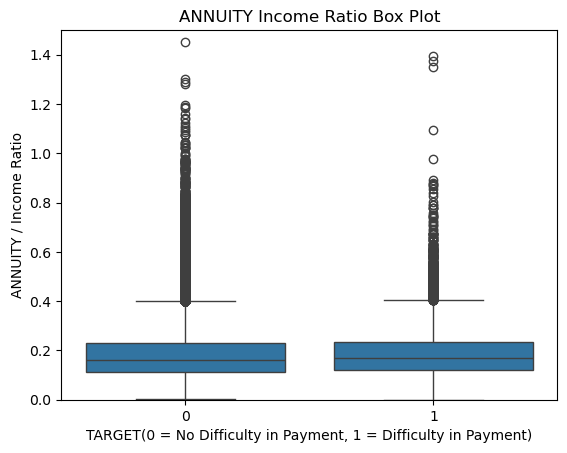

In [13]:
sns.boxplot(x= 'TARGET', y= 'ANNUITY_INCOME_RATIO', data = curr_data)
plt.title('ANNUITY Income Ratio Box Plot')
plt.xlabel('TARGET(0 = No Difficulty in Payment, 1 = Difficulty in Payment)')
plt.ylabel('ANNUITY / Income Ratio')
plt.ylim(0,1.5)
plt.show()

# Observation:Customers whose monthly loan installments consume a larger 
# share of their income are more likely to face payment difficulties.
# Higher annuity-to-income ratios indicate tighter monthly cash flow and reduced ability to absorb financial shocks.

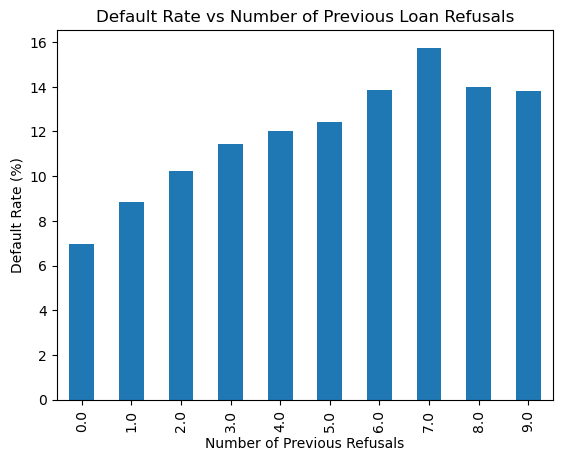

In [14]:
prev_refused = curr_data.groupby('PREV_REFUSED_COUNT')['TARGET'].mean() * 100
prev_refused.head(10).plot(kind='bar')
plt.title('Default Rate vs Number of Previous Loan Refusals')
plt.ylabel('Default Rate (%)')
plt.xlabel('Number of Previous Refusals')
plt.show()


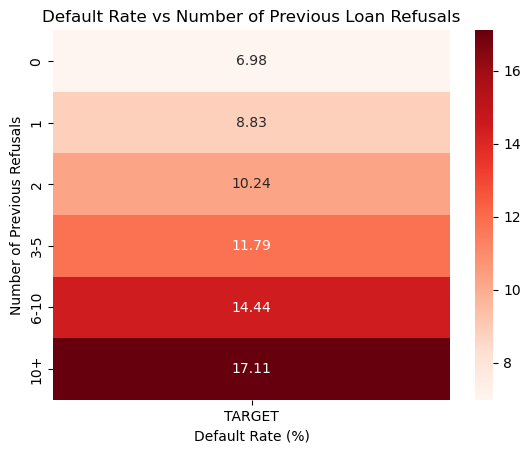

In [15]:
curr_data['REFUSED_GROUP'] = pd.cut(curr_data['PREV_REFUSED_COUNT'],bins=[-1, 0, 1, 2, 5, 10, 100],
    labels=['0', '1', '2', '3-5', '6-10', '10+'])
heat_data = curr_data.pivot_table(
    values='TARGET',
    index='REFUSED_GROUP',
    aggfunc='mean'
) * 100
sns.heatmap(heat_data ,annot=True , fmt='.2f', cmap='Reds')
plt.title('Default Rate vs Number of Previous Loan Refusals')
plt.ylabel('Number of Previous Refusals')
plt.xlabel('Default Rate (%)')
plt.show()
# Obsevations: The higher the number of previous refused loans, the higher the default rate

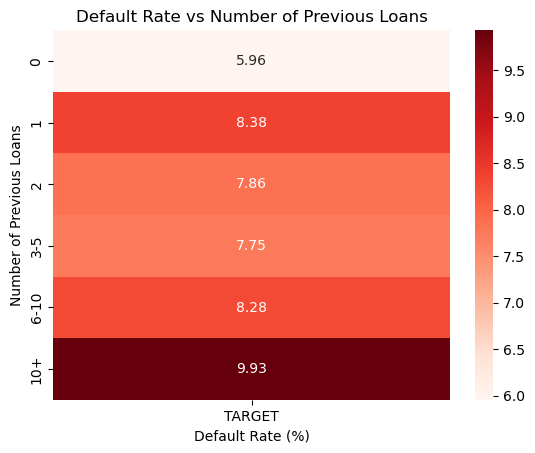

In [16]:
loan_bins = pd.cut(curr_data['PREV_LOAN_COUNT'],bins=[-1, 0, 1, 2, 5, 10, 100],
    labels=['0', '1', '2', '3-5', '6-10', '10+'])
heat_data = curr_data.pivot_table(
    values = 'TARGET'
    , index = loan_bins,
    aggfunc = 'mean'
)*100

sns.heatmap(heat_data ,annot=True , fmt='.2f', cmap='Reds')
plt.title('Default Rate vs Number of Previous Loans')
plt.ylabel('Number of Previous Loans')
plt.xlabel('Default Rate (%)')
plt.show()
# Observations: The higher the number of previous loans, the higher the default rate
# Borrowing experience alone does not steadily reduce risk. Instead,
# customers with very high numbers of previous loans show increased repayment difficulty,
# likely due to accumulated financial obligations.

## 2. Bivariate Analysis

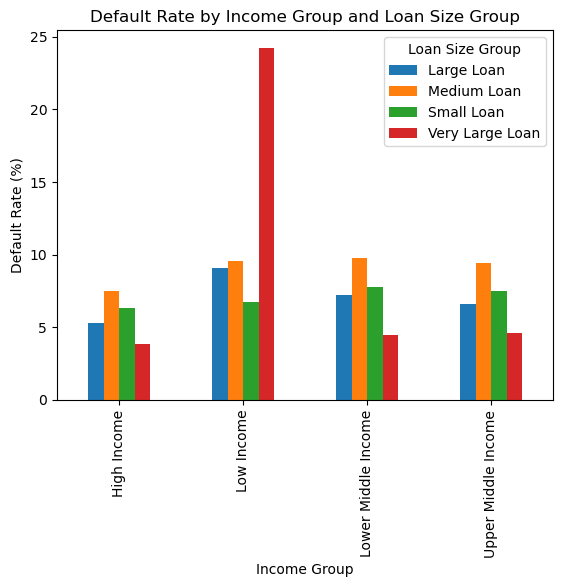

In [20]:
income_loan_size = (curr_data.groupby(['INCOME_GROUP','LOAN_SIZE_GROUP'])['TARGET'].mean()*100).sort_values(ascending=False)
income_loan_size.unstack().plot(kind = 'bar')  
plt.title('Default Rate by Income Group and Loan Size Group')
plt.xlabel('Income Group')
plt.ylabel('Default Rate (%)')
plt.legend(title='Loan Size Group')
plt.show()

# Observations: Loan size alone does not determine risk. The interaction between income level and loan size is crucial.
# Very large loans granted to low-income applicants show significantly elevated default rates,
# indicating a mismatch between repayment capacity and loan exposure.

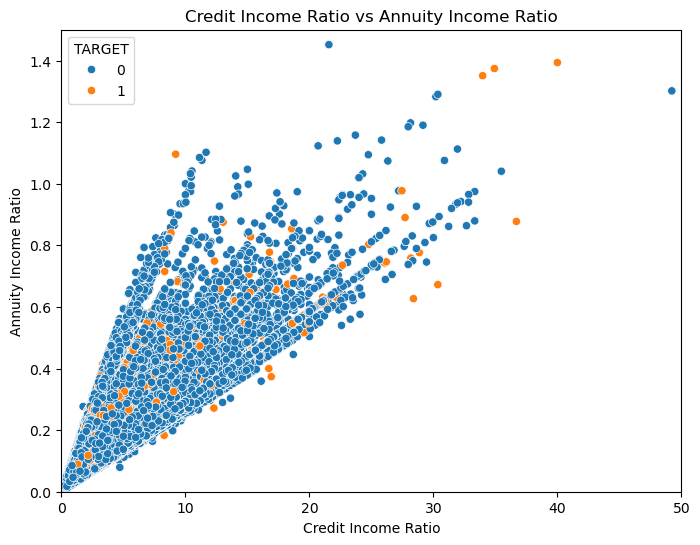

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x = 'CREDIT_INCOME_RATIO', y = 'ANNUITY_INCOME_RATIO', hue = 'TARGET', data = curr_data)
plt.title('Credit Income Ratio vs Annuity Income Ratio')
plt.xlabel('Credit Income Ratio')
plt.ylabel('Annuity Income Ratio')
plt.xlim(0,50)
plt.ylim(0,1.5)
plt.show()

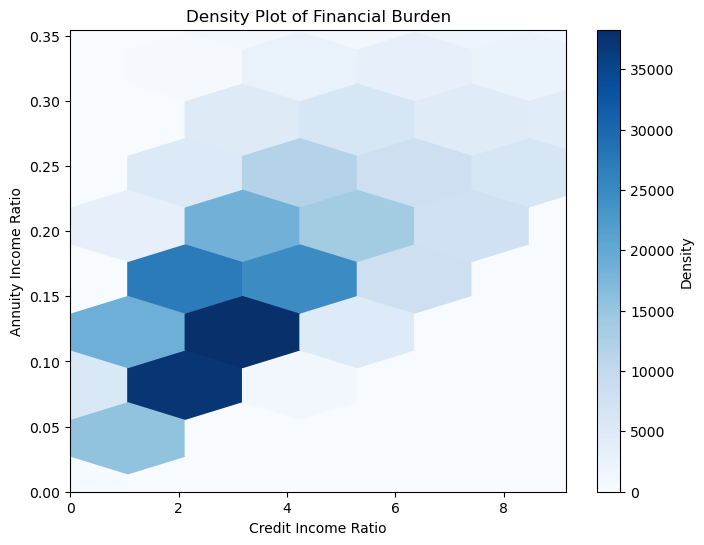

In [19]:
plt.figure(figsize=(8,6))

plt.hexbin(
    curr_data['CREDIT_INCOME_RATIO'],
    curr_data['ANNUITY_INCOME_RATIO'],
    gridsize=40,
    cmap='Blues'
)

plt.colorbar(label='Density')
plt.xlim(0, curr_data['CREDIT_INCOME_RATIO'].quantile(0.95))
plt.ylim(0, curr_data['ANNUITY_INCOME_RATIO'].quantile(0.95))
plt.xlabel('Credit Income Ratio')
plt.ylabel('Annuity Income Ratio')
plt.title('Density Plot of Financial Burden')
plt.show()


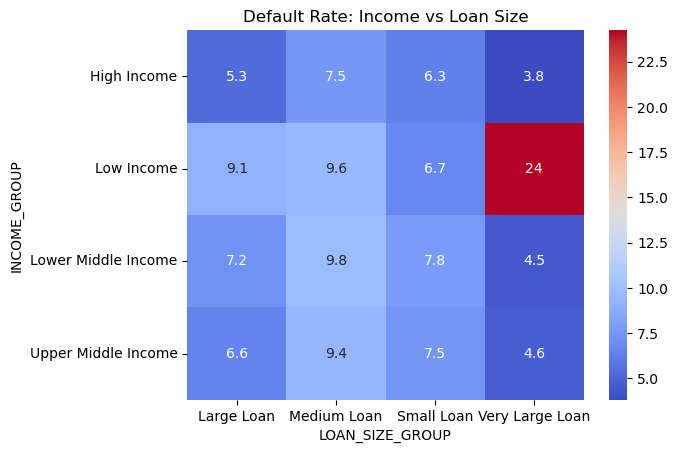

In [51]:
matrix =pd.crosstab(curr_data['INCOME_GROUP'],
            curr_data['LOAN_SIZE_GROUP'],
            values=curr_data['TARGET'],
            aggfunc='mean')*100
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.title("Default Rate: Income vs Loan Size")
plt.show()

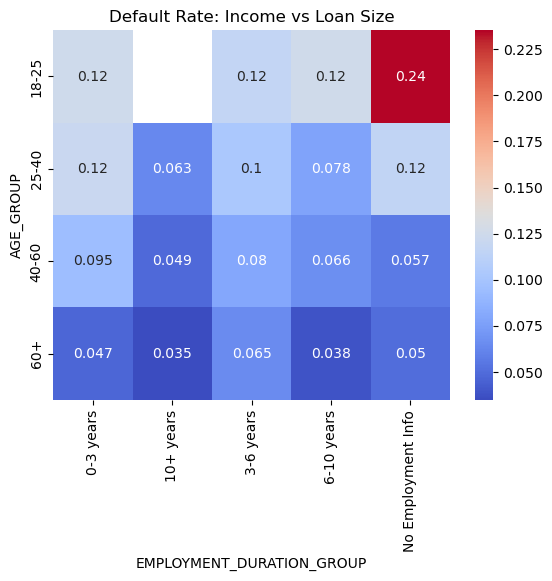

In [47]:
matrix =pd.crosstab(curr_data['AGE_GROUP'],
            curr_data['EMPLOYMENT_DURATION_GROUP'],
            values=curr_data['TARGET'],
            aggfunc='mean')
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.title("Default Rate: Income vs Loan Size")
plt.show()

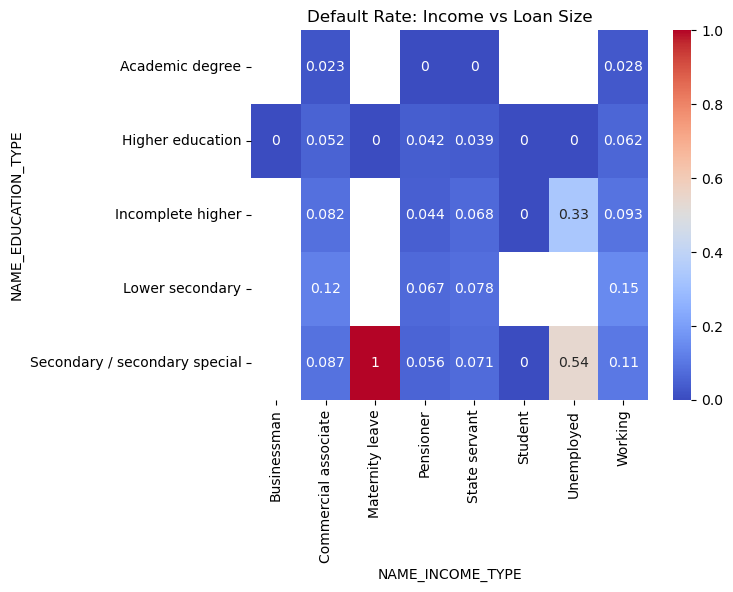

In [52]:
matrix =pd.crosstab(curr_data['NAME_EDUCATION_TYPE'],
            curr_data['NAME_INCOME_TYPE'],
            values=curr_data['TARGET'],
            aggfunc='mean')
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.title("Default Rate: Income vs Loan Size")
plt.show()

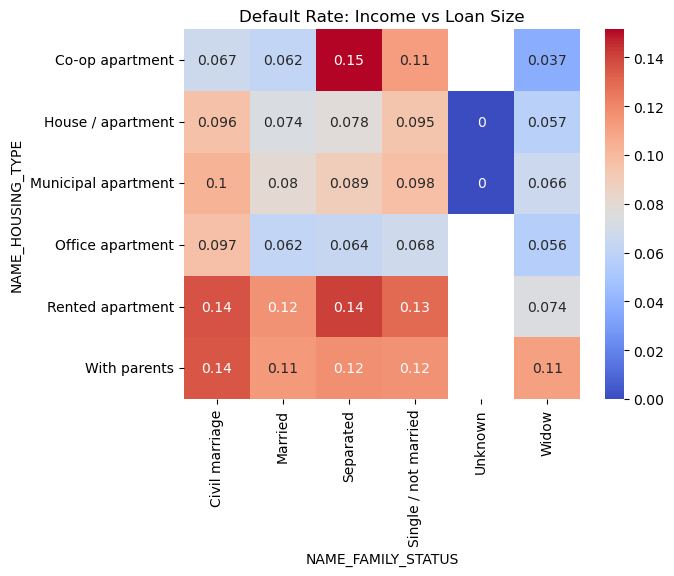

In [53]:
matrix =pd.crosstab(curr_data['NAME_HOUSING_TYPE'],
            curr_data['NAME_FAMILY_STATUS'],
            values=curr_data['TARGET'],
            aggfunc='mean')

sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.title("Default Rate: Income vs Loan Size")
plt.show()

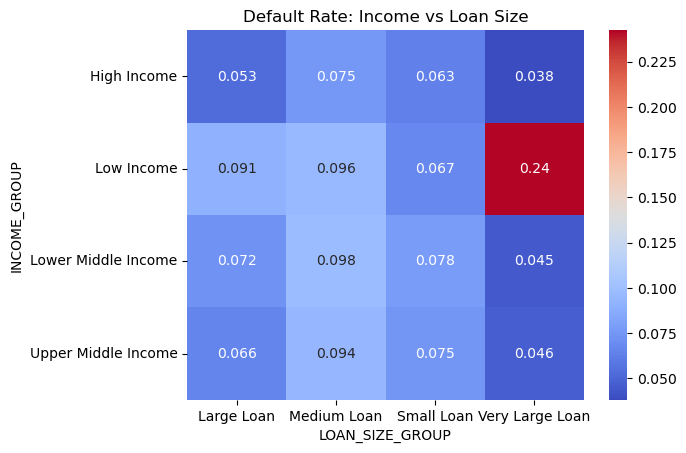

In [45]:
matrix = pd.crosstab(curr_data['INCOME_GROUP'],
                     curr_data['LOAN_SIZE_GROUP'],
                     values=curr_data['TARGET'],
                     aggfunc='mean')

sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.title("Default Rate: Income vs Loan Size")
plt.show()


# 📊 Exploratory Data Analysis Summary: Loan Default Risk

## 🎯 Objective
The purpose of this analysis was to identify patterns and relationships between customer attributes and loan default (`TARGET`) to understand which factors increase credit risk.

---

## 🔍 Univariate Insights

- Income, credit, and annuity variables show **skewed distributions** with presence of outliers
- Majority of customers fall in **middle income and middle age ranges**
- Default class is **imbalanced**, with fewer defaults compared to non-defaults

---

## 🔗 Bivariate Insights (Feature vs Default)

Key relationships observed between individual features and loan default:

- **Income vs Default**  
  Lower income customers show **higher default probability**

- **Credit to Income Ratio**  
  Customers with higher **credit burden relative to income** show significantly higher default rates

- **Annuity to Income Ratio**  
  Higher repayment burden leads to **increased likelihood of default**

- **Age vs Default**  
  Younger applicants show **higher default rates**, while older applicants are more stable

- **Employment Duration vs Default**  
  Customers with **short or unstable employment history** have higher risk compared to long-tenure employees

---

## 🔥 Multivariate Insights (Combined Risk Segments)

### 1️⃣ Income Group × Loan Size
- Low income customers taking **large or very large loans** show the **highest default rates (~24%)**
- High income groups show consistently **low default across all loan sizes**

### 2️⃣ Age × Employment Duration
- **Young applicants (18–25)** with **short or unknown employment** have the highest risk
- Default risk **decreases with age and job stability**

### 3️⃣ Education × Income Type
- **Lower education + unstable income source (unemployed/maternity leave)** shows extremely high default
- **Higher education + stable employment** shows lowest risk

### 4️⃣ Housing Type × Family Status
- **Rented housing or living with parents** is associated with higher default
- **Married customers and owned housing** show lower risk
- Combined financial and social instability leads to the **highest default segments**

---

##  Key Risk Drivers Identified

The most important factors influencing loan default are:

1. High **credit-to-income ratio**
2. Low income combined with **large loan size**
3. **Short or unstable employment duration**
4. Younger age group
5. **Low education with unstable income source**
6. **Housing and family instability**

---

## Overall Conclusion

The analysis shows that loan default risk is strongly influenced by a combination of:

- Financial capacity (income vs loan burden)
- Employment stability
- Demographic factors (age, education)
- Socio-economic stability (housing and family status)

Customers with stable income, long employment history, higher education, and stable housing/family conditions show **significantly lower default risk**, while financially and socially unstable segments show **elevated default probability**.

These insights can be used to improve **credit risk assessment, customer segmentation, and lending decisions**.
